In [1]:
from dataclasses import replace, dataclass
from typing import List, Tuple
import pandas as pd
from typing import Literal, Optional 
import pandas as pd 

from src.dataloading.epidataorchestration import EpiConfig, EpiDataOrchestrator

Entire regimen we've been studying is:

min_date        = '2011-06-01'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'

Fixed origin expanding window:
splits = [
    ('2011-06-01', '2014-06-01', '2015-06-01', '2016-06-01'),
    ('2011-06-01', '2015-06-01', '2016-06-01', '2017-06-01'),
    ('2011-06-01', '2016-06-01', '2017-06-01', '2018-06-01'),
    ('2011-06-01', '2017-06-01', '2018-06-01', '2019-06-01'),
    ('2011-06-01', '2018-06-01', '2019-06-01', '2020-06-01'),
]

Expanding window:
splits = [
    ('2011-06-01', '2014-06-01', '2015-06-01', '2016-06-01'),
    ('2012-06-01', '2015-06-01', '2016-06-01', '2017-06-01'),
    ('2013-06-01', '2016-06-01', '2017-06-01', '2018-06-01'),
    ('2014-06-01', '2017-06-01', '2018-06-01', '2019-06-01'),
    ('2015-06-01', '2018-06-01', '2019-06-01', '2020-06-01'),
]

In [2]:
from dataclasses import dataclass, field
from typing import Literal
import pandas as pd

@dataclass
class CrossValidationEpiConfig:

    min_date        : str
    max_date        : str
    num_folds       : int
    train_years     : int
    val_years       : int
    test_years      : int
    method          : Literal['fixed_origin', 'rolling_window']

    splits_         : dict = field(default_factory=dict, init=False, repr=False)

    def __post_init__(self):
        self._validate()
        self._set_splits()

    def _validate(self):
        min_dt = pd.Timestamp(self.min_date)
        max_dt = pd.Timestamp(self.max_date)

        # Check a single fold fits
        single_fold_end = (
            min_dt
            + pd.DateOffset(years=self.train_years)
            + pd.DateOffset(years=self.val_years)
            + pd.DateOffset(years=self.test_years)
        )
        if single_fold_end > max_dt:
            raise ValueError(
                f"Date range {self.min_date} to {self.max_date} is too short "
                f"for train/val/test = {self.train_years}/{self.val_years}/{self.test_years} years."
            )
        
        if self.method == 'fixed_origin':
            last_test_end = (
                min_dt
                + pd.DateOffset(years=self.train_years + self.num_folds - 1)
                + pd.DateOffset(years=self.val_years)
                + pd.DateOffset(years=self.test_years)
            )
        elif self.method == 'rolling_window':
            last_test_end = (
                min_dt
                + pd.DateOffset(years=self.num_folds - 1)  # rolling offset
                + pd.DateOffset(years=self.train_years)
                + pd.DateOffset(years=self.val_years)
                + pd.DateOffset(years=self.test_years)
            )

        else:
            raise ValueError(f'{self.method} invalid method')

        if last_test_end > max_dt:
            raise ValueError(
                f"{self.num_folds} folds with these window sizes exceed the available date range. "
                f"Last fold would end {last_test_end.date()}, but max_date is {self.max_date}."
            )

                      

    def _set_splits(self):
        min_dt = pd.Timestamp(self.min_date)
        max_dt = pd.Timestamp(self.max_date)

        for fold_idx in range(self.num_folds):

            if self.method == 'fixed_origin':
                train_start = min_dt
                train_end   = min_dt + pd.DateOffset(years=self.train_years + fold_idx)

            elif self.method == 'rolling_window':
                train_start = min_dt + pd.DateOffset(years=fold_idx)
                train_end   = train_start + pd.DateOffset(years=self.train_years)

            else:
                raise ValueError('invalid method')
            
            fold_min_date       = train_start 
            fold_trainval_split = train_end 
            fold_valtest_split  = train_end + pd.DateOffset(years=self.val_years)
            fold_max_date       = fold_valtest_split + pd.DateOffset(years=self.test_years)

            if fold_max_date > max_dt:
                raise ValueError(f"Fold {fold_idx} exceeds max_date. Reduce num_folds.")

            self.splits_[fold_idx] = {
                'min_date'          : fold_min_date.strftime('%Y-%m-%d'),
                'trainval_split'    : fold_trainval_split.strftime('%Y-%m-%d'),
                'valtest_split'     : fold_valtest_split.strftime('%Y-%m-%d'),
                'max_date'          : fold_max_date.strftime('%Y-%m-%d')
            }

    def summary(self):
        print(f"\nCV Config — method: {self.method}, folds: {self.num_folds}\n")
        header = f"{'Fold':<6} {'Min Date':<14} {'Train/Val':<14} {'Val/Test':<14} {'Max Date':<14}"
        print(header)
        print("-" * len(header))
        for fold_idx, s in self.splits_.items():
            print(
                f"{fold_idx:<6} {s['min_date']:<14} {s['trainval_split']:<14} "
                f"{s['valtest_split']:<14} {s['max_date']:<14} "
            )

In [3]:
cfg = CrossValidationEpiConfig(
    min_date    = '2011-06-01',
    max_date    = '2020-06-01',
    num_folds   = 5,
    train_years = 3,
    val_years   = 1,
    test_years  = 1,
    method      = 'rolling_window'
)

cfg.summary()


CV Config — method: rolling_window, folds: 5

Fold   Min Date       Train/Val      Val/Test       Max Date      
------------------------------------------------------------------
0      2011-06-01     2014-06-01     2015-06-01     2016-06-01     
1      2012-06-01     2015-06-01     2016-06-01     2017-06-01     
2      2013-06-01     2016-06-01     2017-06-01     2018-06-01     
3      2014-06-01     2017-06-01     2018-06-01     2019-06-01     
4      2015-06-01     2018-06-01     2019-06-01     2020-06-01     


In [4]:
from src.utils import get_data_env
from src.dataloading import EpiConfig, EpiDataOrchestrator

from src.dataloading import BaseLineDataLoaderManager
from src.models import PersistenceModel, ClimateologyModel, ConstantModel, ClimaScaleModel

@dataclass
class EpiFold:

    foldconfig:             EpiConfig 
    foldepidataorchestrator:EpiDataOrchestrator 


@dataclass
class FoldCollection:

    epifolds: List[EpiFold]
    foldconfig: CrossValidationEpiConfig
    

    def __iter__(self):
        return iter(self.epifolds)
    
    def __len__(self):
        return len(self.epifolds)

    def __getitem__(self, idx: int) -> EpiFold:
        return self.epifolds[idx]

In [5]:
# get data
disease_name    = 'influenza'
nuts_level      = 'nuts3'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 3
sequence_length = 4
lag_num         = 1

epifolds = []

for fold, fold_dates in cfg.splits_.items():

    config = EpiConfig(
        disease             = disease_name,
        min_date            = fold_dates['min_date'], 
        max_date            = fold_dates['max_date'],
        horizon_size        = horizon_size,
        sequence_length     = sequence_length,
        horizon_leadtime    = horizon_leadtime,
        lag_num             = lag_num,
        nuts_level          = nuts_level,
        log_transform       = ['incidence'],
        split_berlin        = split_berlin,
        split_trainval      = fold_dates['trainval_split'], 
        split_valtest       = fold_dates['valtest_split'],
        target_column       = 'incidence',
        lag_column          = 'incidence',  
        verbose             = 0  ,
        predict_difference=False
        )    

    data_orchestrator = (EpiDataOrchestrator(config).build())

    epifolds.append(EpiFold(config, data_orchestrator))

foldcollection = FoldCollection(epifolds, cfg)


In [6]:
models = {}

for fold_idx, fold in enumerate(foldcollection):

    baseline_data            = BaseLineDataLoaderManager(fold.foldepidataorchestrator)
    
    constant_predictor      = ConstantModel(baseline_data,name      = f'fold{fold_idx+1}')
    persistence_predictor   = PersistenceModel(baseline_data,name   = f'fold{fold_idx+1}')
    climateology            = ClimateologyModel(baseline_data,name  = f'fold{fold_idx+1}')
    climascale              = ClimaScaleModel(baseline_data,name    = f'fold{fold_idx+1}')

    constant_predictor.set_model_hparams(0)
    constant_predictor.forecast('test')
    persistence_predictor.forecast('test')
    climateology.forecast('test')
    # climascale.forecast('test')

    models_fold = [persistence_predictor,climateology]
    models[f'fold{fold_idx+1}'] = models_fold

In [7]:
# model_evaluations_foldwise 
from src.evaluation import Evaluator

persistences    = []
climateologies  = []


for fold_idx, fold in enumerate(foldcollection):
    for model_idx, model in enumerate(models[f'fold{fold_idx + 1}']):
        if model.__class__.__name__ == 'PersistenceModel':
            persistences.append(model)
        if model.__class__.__name__ == 'ClimateologyModel':
            climateologies.append(model)


evaluators = {
    'persistence':  Evaluator(persistences).add_evaluation(),
    'climateology': Evaluator(climateologies).add_evaluation()
}

figure_raw1 = (evaluators['persistence'].plotter.plot_metric_compilation(metrics = ['ccc','r2'])
            .change_figsize(14,5)
            .layout.set_ylim([-1,1], ax = 1)
            .labels.change_suptitle(f'persistence', fontweight='bold', fontsize=14)
            )



figure_raw2 = (evaluators['climateology'].plotter.plot_metric_compilation(metrics = ['ccc','r2'])
            .change_figsize(14,5)
            .layout.set_ylim([-1,1], ax = 1)
            .labels.change_suptitle(f'persistence', fontweight='bold', fontsize=14)
            )


computing metrics:  88%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████                   | 7/8 [00:05<00:00,  1.23it/s]/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/metrics.py:58: RuntimeWarning: invalid value encountered in scalar divide
  r2=  float(1 - ss_res/ ss_tot)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/metrics.py:58: RuntimeWarning: divide by zero encountered in scalar divide
  r2=  float(1 - ss_res/ ss_tot)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/metrics.py:58: RuntimeWarning: invalid value encountered in scalar divide
  r2=  float(1 - ss_res/ ss_tot)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/metrics.py:58: RuntimeWarning: invalid value encountered in scalar divide
  r2=  float(1 - ss_res/ ss_tot)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/metrics.py:58: 

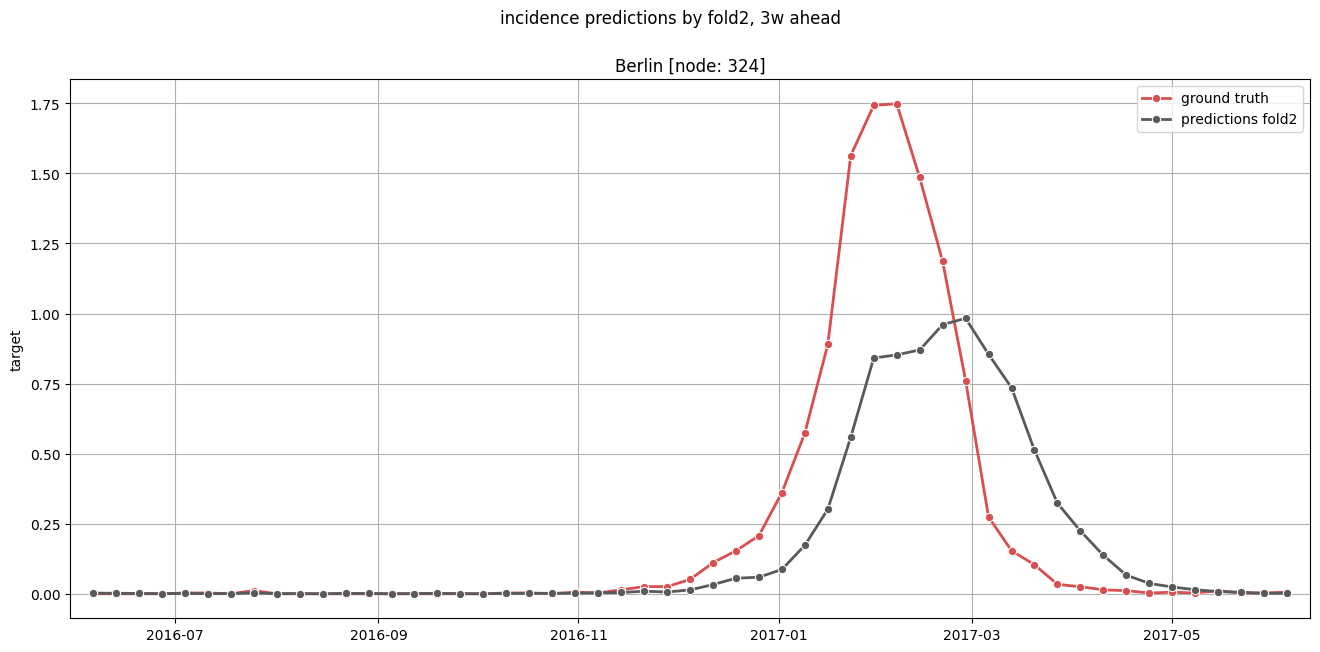

In [8]:
climateologies[1].show_forecasts(324).show()

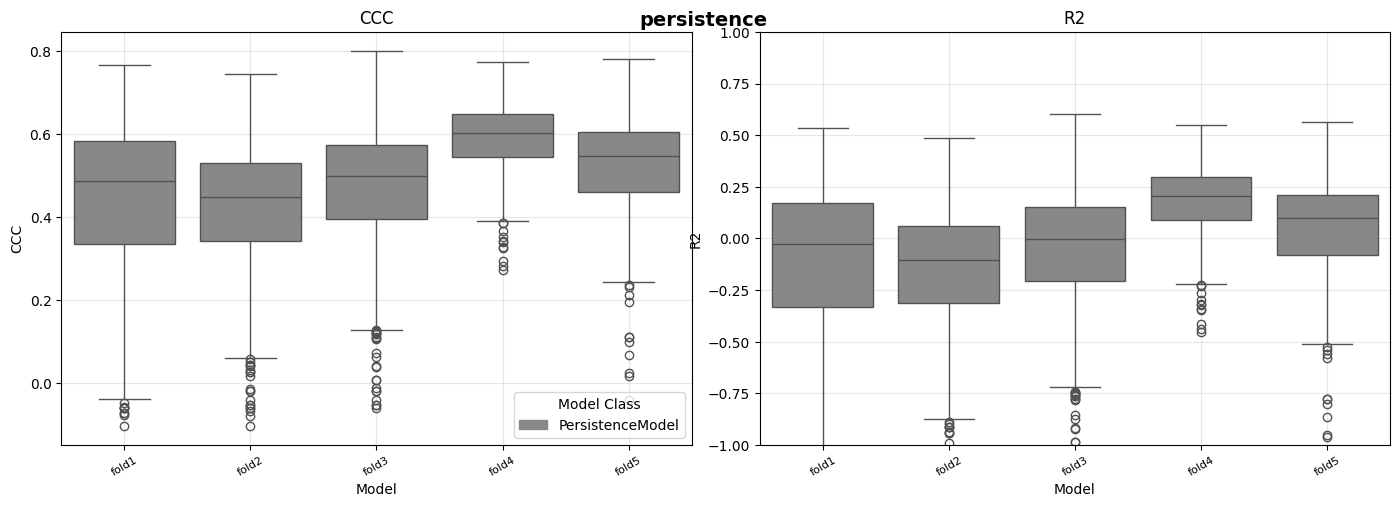

In [9]:
figure_raw1.show()


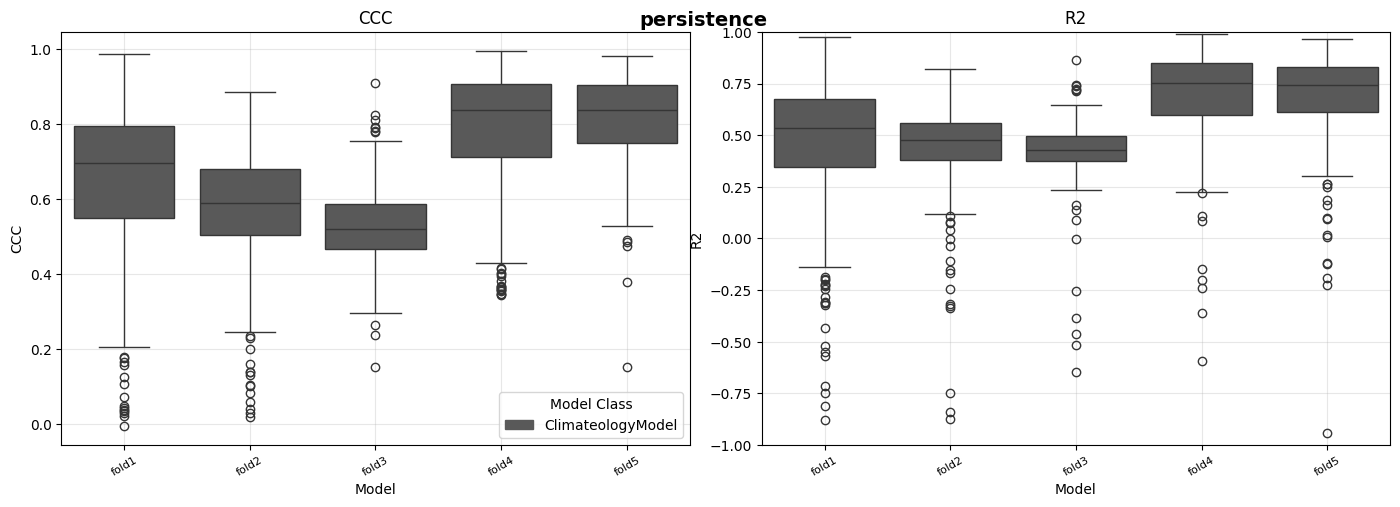

In [10]:
figure_raw2.show()

In [ ]:
models = {}

n_epochs        = 500
lr              = 0.0005
min_delta       = 0.0001
loss            = 'mse'

model_hparams = {
    'hidden_size'     : 64,    # was 128 — halve it
    'gat_hidden_dim'  : 32,    # was 64 — halve it  
    'num_heads'       :2,     # keep
    'temporal_layers' : 1,     # was 2 — single LSTM layer
    'dropout'         : 0.3,   # was 0.2 — slightly more aggressive
}

global_hparams = {
    "lr"                : lr,
    'optimizer'         : 'adamw',
    'optimizer_kwargs'  : {'weight_decay' : 1e-4},
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }

from src.dataloading.dataloaders import GraphDataLoaderManager
from src.models import GATv2LSTMModel

for fold_idx, fold in enumerate(foldcollection):

    graphdataloader_ig       = GraphDataLoaderManager(fold.foldepidataorchestrator).retrieve_static_graph('identity_graph').build()
    graphdataloader_gn       = GraphDataLoaderManager(fold.foldepidataorchestrator).retrieve_static_graph('geographical_neighbors1').build()
    graphdataloader_cm       = GraphDataLoaderManager(fold.foldepidataorchestrator).retrieve_static_graph('static_commuter24_1').build()    
    
    gatv2_ig = GATv2LSTMModel(graphdataloader_ig, name = f'ig_{fold_idx+1}', verbose = 2)
    gatv2_ig.set_model_hparams(**model_hparams)
    gatv2_ig.set_global_hparams(**global_hparams)
    gatv2_ig.train()
    gatv2_ig.forecast()

    gatv2_gn = GATv2LSTMModel(graphdataloader_gn, name = f'gm_{fold_idx+1}', verbose = 2)
    gatv2_gn.set_model_hparams(**model_hparams)
    gatv2_gn.set_global_hparams(**global_hparams)
    gatv2_gn.train()
    gatv2_gn.forecast()

    gatv2_cm = GATv2LSTMModel(graphdataloader_cm, name = f'cm_{fold_idx+1}', verbose = 2)
    gatv2_cm.set_model_hparams(**model_hparams)
    gatv2_cm.set_global_hparams(**global_hparams)
    gatv2_cm.train()
    gatv2_cm.forecast()

    models_fold = [gatv2_ig,gatv2_gn,gatv2_cm]
    models[f'fold{fold_idx+1}'] = models_fold


==                     ig_1                     ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 3, 4), y=(400, 1), edge_index=(2, 400), edge_weight=(400,))
Epoch 001 train loss: 0.9695, val loss: 2.1822 ✓ (new best)
Epoch 002 train loss: 0.7937, val loss: 2.1826 (patience: 1/20)
Epoch 003 train loss: 0.6774, val loss: 2.0152 ✓ (new best)
Epoch 004 train loss: 0.6446, val loss: 1.9082 ✓ (new best)
Epoch 005 train loss: 0.6143, val loss: 1.8624 ✓ (new best)
Epoch 006 train loss: 0.5965, val loss: 1.7865 ✓ (new best)
Epoch 007 train loss: 0.5773, val loss: 1.7510 ✓ (new best)
Epoch 008 train loss: 0.5656, val loss: 1.7889 (patience: 1/20)
Epoch 009 train loss: 0.5560, val loss: 1.6523 ✓ (new best)
Epoch 010 train loss: 0.5272, val loss: 1.8277 (patience: 1/20)
Epoch 011 train loss: 0.5339, val loss: 1.5789 ✓ (new best)
Epoch 012 train loss: 0.4979, val loss: 1.8934 (patience: 1/20)
Epoch 013 train loss: 0.5340, val loss: 1.4954 ✓ (new best)
Epoch 014 tr

In [16]:
# model_evaluations_foldwise 
from src.evaluation import Evaluator

igs    = []
gns  = []
cms = []


for fold_idx, fold in enumerate(foldcollection):

    igs.append(models[f'fold{fold_idx + 1}'][0])
    gns.append(models[f'fold{fold_idx + 1}'][1])
    cms.append(models[f'fold{fold_idx + 1}'][2])    

evaluators = {
    'identity graphs':  Evaluator(igs).add_evaluation(),
    'geometric graphs': Evaluator(gns).add_evaluation(),
    'commuter graphs':  Evaluator(cms).add_evaluation()
}

figure_raw1 = (evaluators['identity graphs'].plotter.plot_metric_compilation(metrics = ['ccc','r2'])
            .change_figsize(14,5)
            .layout.set_ylim([-1,1], ax = 1)
            .labels.change_suptitle(f'identity graphs', fontweight='bold', fontsize=14)
            )



figure_raw2 = (evaluators['geometric graphs'].plotter.plot_metric_compilation(metrics = ['ccc','r2'])
            .change_figsize(14,5)
            .layout.set_ylim([-1,1], ax = 1)
            .labels.change_suptitle(f'geometric', fontweight='bold', fontsize=14)
            )


figure_raw3 = (evaluators['commuter graphs'].plotter.plot_metric_compilation(metrics = ['ccc','r2'])
            .change_figsize(14,5)
            .layout.set_ylim([-1,1], ax = 1)
            .labels.change_suptitle(f'commuter', fontweight='bold', fontsize=14)
            )


computing metrics:  88%|███████████████████████████████████████████████████████████████         | 7/8 [00:05<00:00,  1.26it/s]/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/metrics.py:58: RuntimeWarning: divide by zero encountered in scalar divide
  r2=  float(1 - ss_res/ ss_tot)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/metrics.py:58: RuntimeWarning: divide by zero encountered in scalar divide
  r2=  float(1 - ss_res/ ss_tot)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/metrics.py:58: RuntimeWarning: divide by zero encountered in scalar divide
  r2=  float(1 - ss_res/ ss_tot)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/metrics.py:58: RuntimeWarning: divide by zero encountered in scalar divide
  r2=  float(1 - ss_res/ ss_tot)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/metrics.py:58: RuntimeWarning: divide by zero encountered in scalar divide
  r2=  float(1 - 

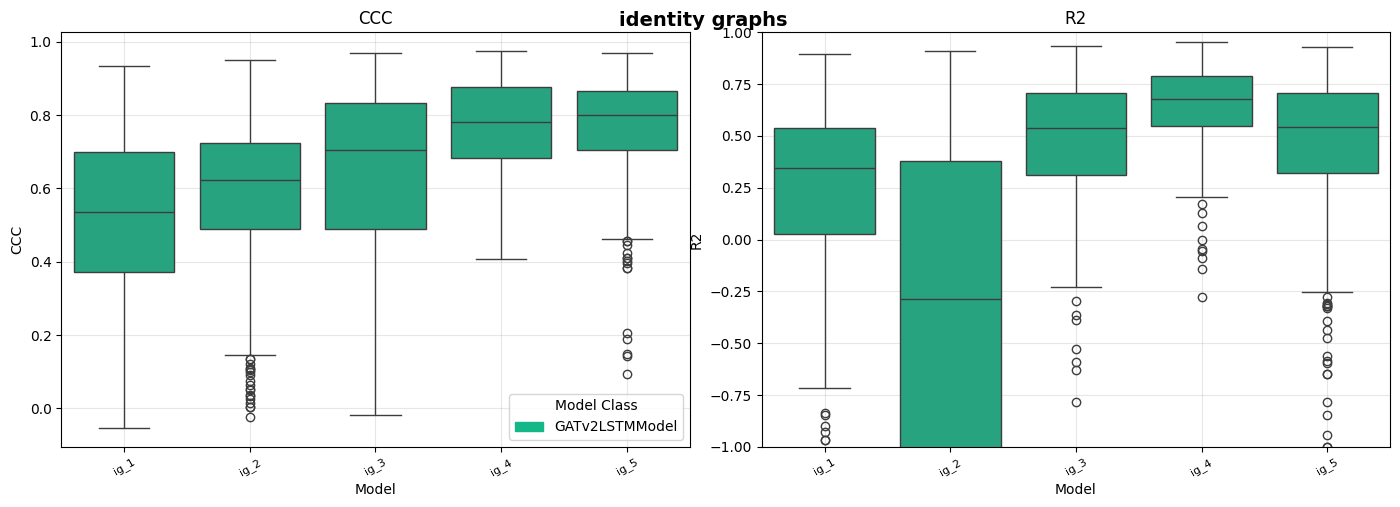

In [17]:
figure_raw1.show()

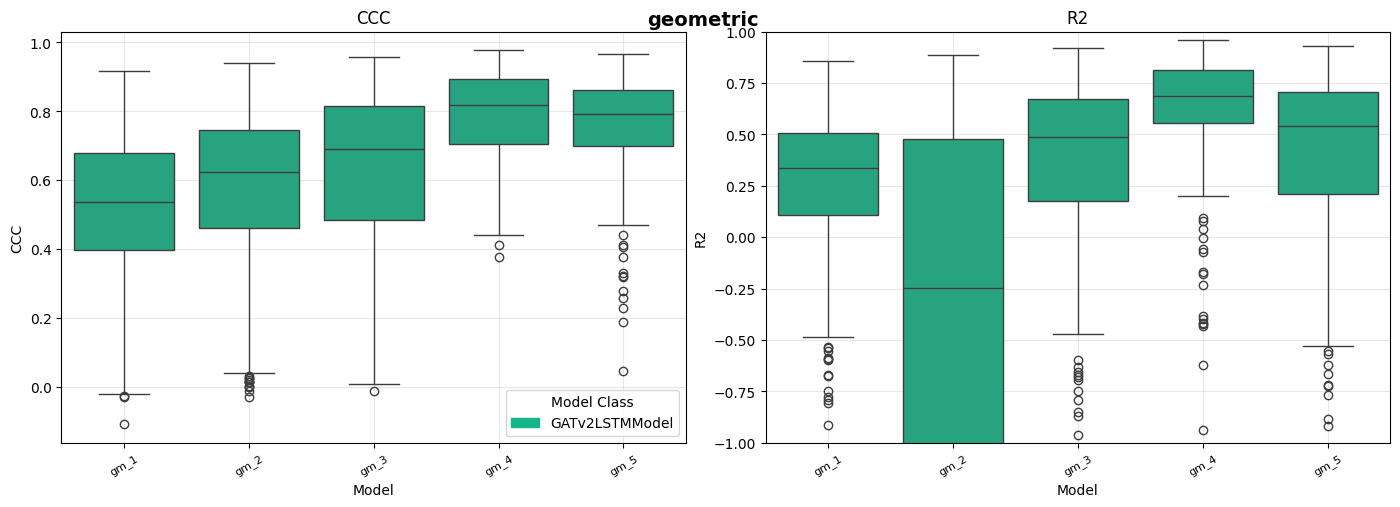

In [18]:
figure_raw2.show()

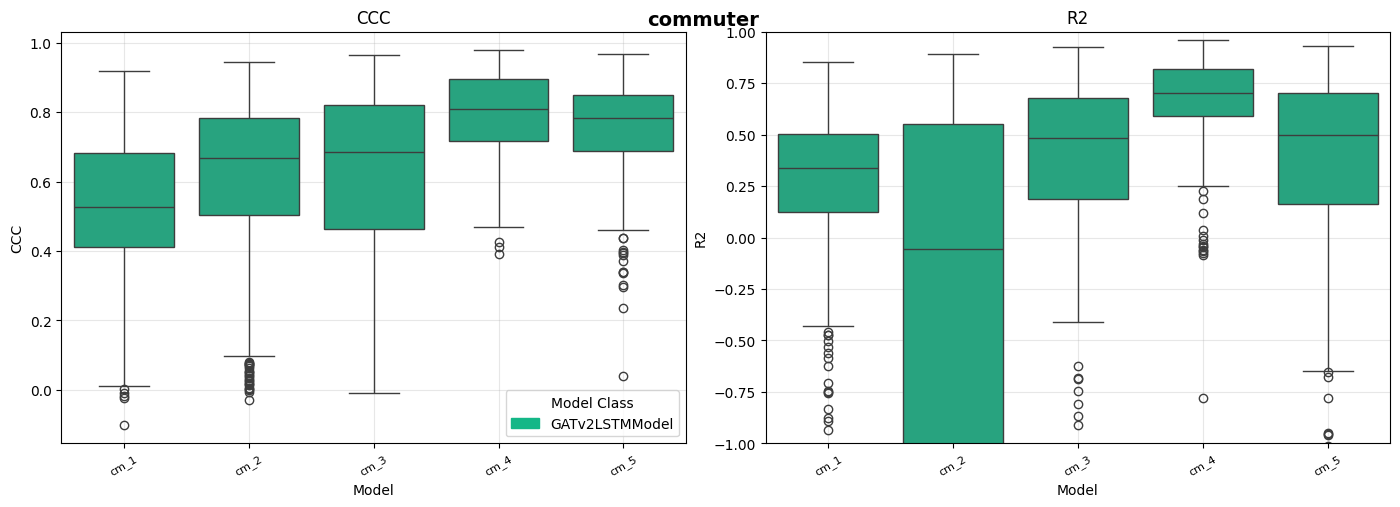

In [15]:
figure_raw3.show()

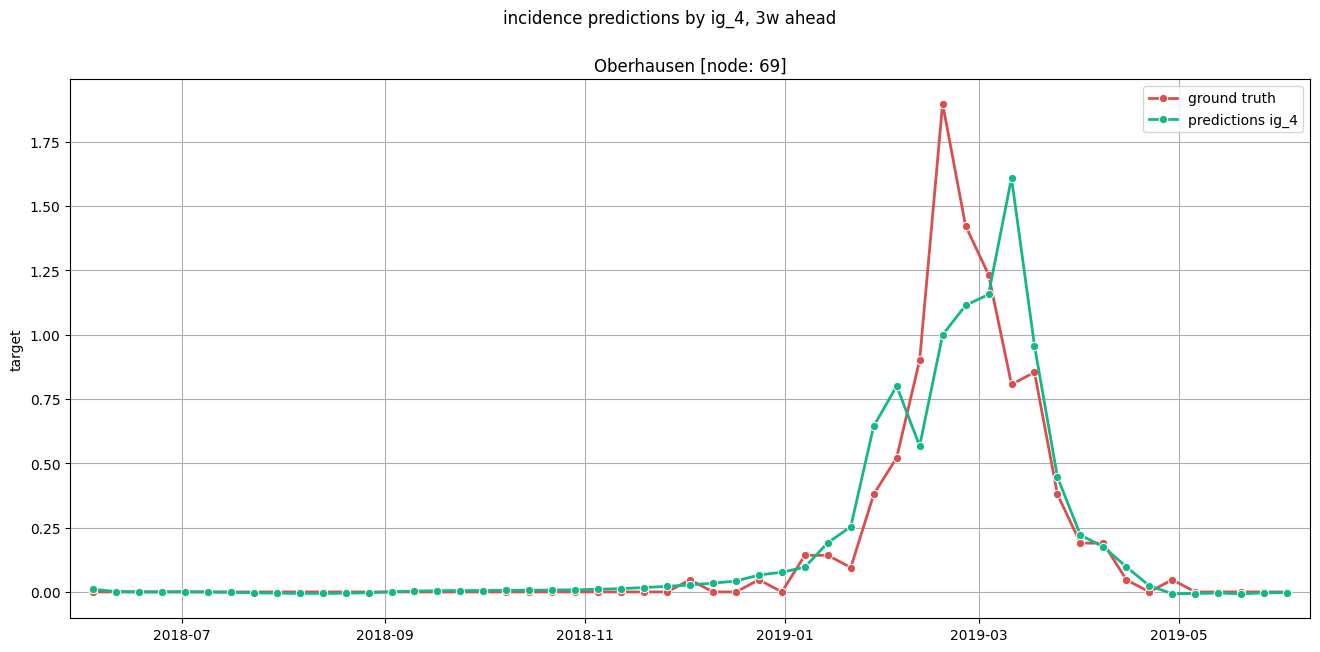

In [28]:
igs[3].show_forecasts(69).show()